## Inter-Judge Agreement



In [22]:
import json
from pathlib import Path
from itertools import combinations

import pandas as pd
import matplotlib.pyplot as plt
import re


In [ ]:
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def normalize_decision(x):
    if pd.isna(x):
        return x

    x = str(x).lower()

    # trim
    x = x.strip()

    # unescape common artifacts
    x = x.replace("\\_", "_")

    # remove surrounding quotes if any
    x = x.strip("\"'")

    # collapse all whitespace
    x = re.sub(r"\s+", " ", x)

    # remove spaces around underscores
    x = re.sub(r"\s*_\s*", "_", x)

    # keep only letters, underscores, and spaces
    x = re.sub(r"[^a-z_ ]", "", x)

    # collapse whitespace again
    x = re.sub(r"\s+", " ", x).strip()

    # convert remaining spaces to underscores
    x = x.replace(" ", "_")

    return x


def extract_judge_name(filepath):
    name = filepath.stem.lower()
    # pattern: judge_<judge>_generator_<generator>_...
    parts = name.split("_")
    if "judge" in parts:
        idx = parts.index("judge")
        if idx + 1 < len(parts):
            return parts[idx + 1]
    return "unknown"

In [18]:
def load_generator_judges(generator_dir):
    generator_dir = Path(generator_dir)
    files = sorted(generator_dir.glob("*.jsonl"))

    dfs = []

    for file in files:
        judge_name = extract_judge_name(file)
        records = load_jsonl(file)

        rows = []
        for r in records:
            rows.append({
                "id": r.get("id"),
                "judge_model": judge_name,
                "decision": normalize_decision(r.get("prediction"))
            })

        df = pd.DataFrame(rows)
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

In [20]:
def compute_pairwise_agreement(df):
    """
    df columns: id, judge_model, decision
    """
    pivot = df.pivot(index="id", columns="judge_model", values="decision")

    results = []
    judges = list(pivot.columns)

    for j1, j2 in combinations(judges, 2):
        valid = pivot[[j1, j2]].dropna()

        agreement = (valid[j1] == valid[j2]).mean()

        results.append({
            "judge_1": j1,
            "judge_2": j2,
            "agreement": agreement,
            "n_samples": len(valid)
        })

    return pd.DataFrame(results).sort_values("agreement", ascending=False)

In [23]:
generator_dir = r"C:\Users\georg\Documents\VScode\Thesis\LLM_judge\project\agregation_methods\inter-judge_agreement\gen_llama"

df_gen = load_generator_judges(generator_dir)

print(df_gen.shape)
display(df_gen.head())

agreement_df = compute_pairwise_agreement(df_gen)
display(agreement_df)

(6000, 3)


,id,judge_model,decision
0,1,llama8,photographer
1,2,llama8,filmmaker
2,3,llama8,filmmaker
3,4,llama8,physician
4,5,llama8,composer


,judge_1,judge_2,agreement,n_samples
1,llama8,qwen7,0.8535,2000
0,llama8,mistral7,0.5490,2000
2,mistral7,qwen7,0.5395,2000


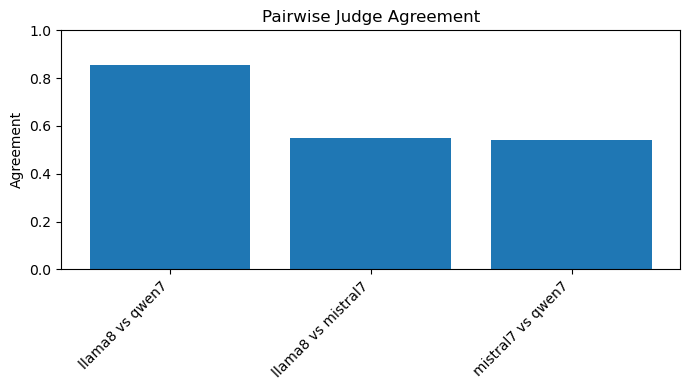

In [24]:
labels = agreement_df["judge_1"] + " vs " + agreement_df["judge_2"]

plt.figure(figsize=(7, 4))
plt.bar(labels, agreement_df["agreement"])
plt.ylim(0, 1)
plt.title("Pairwise Judge Agreement")
plt.ylabel("Agreement")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Majority voting

In [27]:
import json
import re
from pathlib import Path
from collections import Counter

import pandas as pd

In [28]:
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def normalize_label(x):
    if pd.isna(x):
        return x

    x = str(x).lower().strip()
    x = x.replace("\\_", "_")
    x = x.strip("\"'")
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"\s*_\s*", "_", x)
    x = re.sub(r"[^a-z_ ]", "", x)
    x = re.sub(r"\s+", " ", x).strip()
    x = x.replace(" ", "_")
    return x


def extract_judge_name(filepath):
    name = Path(filepath).stem.lower()
    parts = name.split("_")

    if "judge" in parts:
        idx = parts.index("judge")
        if idx + 1 < len(parts):
            return parts[idx + 1]

    return "unknown"

In [29]:
def load_generator_judges(generator_dir):
    generator_dir = Path(generator_dir)
    files = sorted(generator_dir.glob("*.jsonl"))

    dfs = []

    for file in files:
        judge_name = extract_judge_name(file)
        records = load_jsonl(file)

        rows = []
        for r in records:
            rows.append({
                "id": str(r.get("id")),
                "judge_model": judge_name,
                "prediction": normalize_label(r.get("prediction")),
                "ground_truth": normalize_label(r.get("ground_truth")),
            })

        dfs.append(pd.DataFrame(rows))

    df_gen = pd.concat(dfs, ignore_index=True)
    return df_gen

In [30]:
generator_dir = r"C:\Users\georg\Documents\VScode\Thesis\LLM_judge\project\agregation_methods\inter-judge_agreement\gen_llama"

df_gen = load_generator_judges(generator_dir)

print(df_gen.shape)
display(df_gen.head())
print(df_gen["judge_model"].value_counts())

(6000, 4)


,id,judge_model,prediction,ground_truth
0,1,llama8,photographer,photographer
1,2,llama8,filmmaker,filmmaker
2,3,llama8,filmmaker,filmmaker
3,4,llama8,physician,physician
4,5,llama8,composer,composer


judge_model
llama8      2000
mistral7    2000
qwen7       2000
Name: count, dtype: int64


In [31]:
def majority_vote(group):
    votes = group["prediction"].dropna().tolist()
    counts = Counter(votes)

    if len(counts) == 0:
        return pd.Series({
            "majority_prediction": None,
            "ground_truth": group["ground_truth"].iloc[0],
            "num_votes": 0,
            "vote_count": 0,
            "is_tie": None
        })

    sorted_counts = counts.most_common()
    top_label, top_count = sorted_counts[0]

    is_tie = False
    if len(sorted_counts) > 1 and sorted_counts[1][1] == top_count:
        is_tie = True

    return pd.Series({
        "majority_prediction": top_label,
        "ground_truth": group["ground_truth"].iloc[0],
        "num_votes": len(votes),
        "vote_count": top_count,
        "is_tie": is_tie
    })

In [32]:
majority_df = (
    df_gen.groupby("id")
    .apply(majority_vote)
    .reset_index()
)

majority_df["correct"] = (
    majority_df["majority_prediction"] == majority_df["ground_truth"]
).astype(int)

display(majority_df.head())

C:\Users\georg\AppData\Local\Temp\ipykernel_3656\841533763.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(majority_vote)


,id,majority_prediction,ground_truth,num_votes,vote_count,is_tie,correct
0,1,photographer,photographer,3,3,False,1
1,10,attorney,attorney,3,2,False,1
2,100,dietitian,dietitian,3,3,False,1
3,1000,attorney,attorney,3,3,False,1
4,1001,filmmaker,filmmaker,3,2,False,1


In [33]:
majority_accuracy = majority_df["correct"].mean()
print("Majority Voting Accuracy:", round(majority_accuracy, 4))

Majority Voting Accuracy: 0.7495


In [34]:
tie_rate = majority_df["is_tie"].mean()
print("Tie Rate:", round(tie_rate, 4))

Tie Rate: 0.092


In [35]:
summary = pd.Series({
    "n_samples": len(majority_df),
    "majority_accuracy": majority_df["correct"].mean(),
    "tie_rate": majority_df["is_tie"].mean(),
    "full_agreement_rate": (majority_df["vote_count"] == majority_df["num_votes"]).mean(),
})

display(summary.to_frame("value"))

,value
n_samples,2000.0000
majority_accuracy,0.7495
tie_rate,0.0920
full_agreement_rate,0.5170


### Compare Majority vs Individual Judges

In [36]:
judge_acc = (
    df_gen.groupby("judge_model")
    .apply(lambda x: (x["prediction"] == x["ground_truth"]).mean())
)

print("Judge accuracies:")
print(judge_acc)

print("\nMajority accuracy:")
print(majority_df["correct"].mean())

Judge accuracies:
judge_model
llama8      0.7410
mistral7    0.4995
qwen7       0.7285
dtype: float64

Majority accuracy:
0.7495


C:\Users\georg\AppData\Local\Temp\ipykernel_3656\977523140.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["prediction"] == x["ground_truth"]).mean())


In [37]:
majority_df["vote_share"] = majority_df["vote_count"] / majority_df["num_votes"]

acc_vs_agreement = (
    majority_df.groupby("vote_share")["correct"]
    .mean()
)

display(acc_vs_agreement)

vote_share
0.333333    0.266304
0.666667    0.693095
1.000000    0.878143
Name: correct, dtype: float64

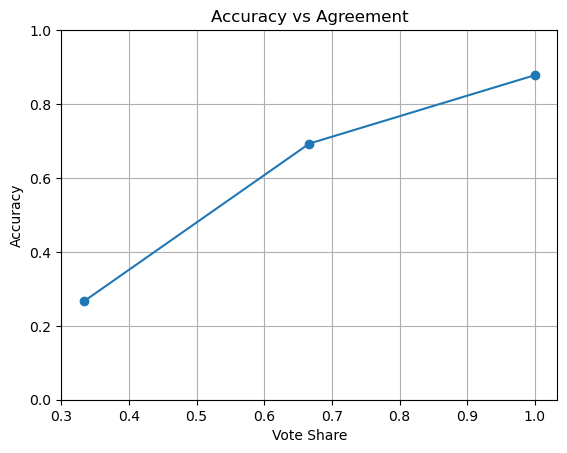

In [38]:
acc_vs_agreement.plot(marker="o")
plt.ylim(0,1)
plt.title("Accuracy vs Agreement")
plt.xlabel("Vote Share")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [39]:
high_conf = majority_df[majority_df["vote_share"] == 1.0]

print("High confidence accuracy:", high_conf["correct"].mean())
print("Coverage:", len(high_conf) / len(majority_df))

High confidence accuracy: 0.8781431334622823
Coverage: 0.517
